<div class="jupyter-biolm-header">
    <img style="float: left; padding-right: 10px; height: 60px" src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/logo.png">
    <p>
    <br>
    <br>
    <br>
    </p>
</div>

# Cover More Sequence Space, Screen Less: Diversity Selection with Embeddings

Cluster your library in sequence space with ESM2 embeddings and select diverse representatives before you screen.

<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://www.svgrepo.com/show/354202/postman-icon.svg" style="height: 15px; float: left; padding-right: 10px;"><a href="https://api.biolm.ai/">  <h5 style="margin: 0;"><b>Postman API Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c3/Python-logo-notext.svg/1869px-Python-logo-notext.svg.png" style="height: 15px; float: left; padding-right: 10px;"><a href="https://docs.biolm.ai/en/latest/index.html"><h5 style="margin: 0;"><b>Python SDK Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
    </tr>
</table>

<br>

---

**What you'll learn:**
- Generating ESM2-8m embeddings via the pipeline SDK
- K-means clustering with silhouette score selection
- PCA visualization of sequence space
- Diversity sampling across clusters

**Requirements:**
```
pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ "biolm-sdk[pipeline]" matplotlib scikit-learn
export BIOLM_TOKEN=your-token-here
```

## Setup

In [1]:
import os
from pathlib import Path
from biolm.pipeline import (
    DataPipeline, DuckDBDataStore,
    ThresholdFilter, RankingFilter,
    ValidAminoAcidFilter, EmbeddingSpec,
    DiversitySamplingFilter,
)

TOKEN = os.environ.get("BIOLM_TOKEN") or os.environ.get("BIOLMAI_TOKEN", "")
if not TOKEN:
    creds = Path.home() / ".biolm" / "credentials"
    legacy = Path.home() / ".biolmai" / "credentials"
    if not creds.exists() and not legacy.exists():
        raise EnvironmentError(
            "Set BIOLM_TOKEN before running, or run `biolm login`.\n"
            "Get a token at https://biolm.ai/ui/accounts/user-api-tokens/"
        )
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

## Peptide library

50 antimicrobial peptides from three families: magainins, defensins, and designed sequences.

In [2]:
MY_50_PEPTIDES = [
    "GIGKFLHSAKKFGKAFVGEIMNS", "GIGKFLHSAGKFGKAFVGEIMKS", "GLFDIIKKIAESF",
    "GLFDIVKKVVGALGSL", "FLPLILRKIVTAL", "GIKKFLGSIWKFIKAFVKEIMN",
    "GLFDIIKKIAESFLPKV", "GIGKFLHSAKKFGKAFV", "GIGKFLHSAK", "GIGKFLHSAKKFGK",
    "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES", "RLFDKIRQVIRKF",
    "KWKLFKKIPKFLHLAKKF", "KWKLFKKIPKFLHLAK", "FKRIVQRIKDFL",
    "RWKIFKKIEKVGRNVRDGIIKAGPAVAVVGQATQIAK",
    "KWKLFKKIEKVGQNIRDGIIKAGPAVAVVGQATQIAK",
    "GIGAVLKVLTTGLPALISWIKRKRQQ", "VDKGSYLPRPTPPRPIYNRN", "GKPRPYSPRPTSHPRPIRV",
    "KLAKLAKKLAKLAK", "LKLLKKLLKLLKKL", "RRWWRRWWRR", "KWKWKWKWKW",
    "RRLCRIVVIRVCR", "RRWQWR", "RWRWRW", "KFLKKAKKFGK",
    "KWKLFKKI", "RLFDKIRQ",
    "ACYCRIPACIAGERRYGTCIYQGRLWAFCC", "GCSKNKGCSVDKECAAFGSR",
    "DCSCFGGKGETACNKCKTPEGKPCTEGKPCK", "GFCKLCCNPACGPNYKGICIDM",
    "AFGKQLAKLAKSKLAKLAKLAK", "KLALKLALKALKAALKLA",
    "WKWLKKWLKKLK", "RWKKWWRRKK", "KFKKLFKKLKK",
    "FLGALFKALSKLL", "ALLKFLLKFLLK", "GLLDFLK",
    "KKLFKKILKYL", "FFKDEL", "ILKKWPWWPWRR",
    "GLWSKIKEVGKEAAKAAAKAAGKAALNAVTGGGKPG",
    "KLKLLLLLKLK", "WKLFKKIKVWK", "KWKWFKKIKVWK", "KLFKKIKVWKK",
]
print(f"{len(MY_50_PEPTIDES)} peptides")

50 peptides


## Embed with ESM2-8m

In [3]:
ds = DuckDBDataStore("cluster_demo.duckdb")

cp = DataPipeline(sequences=MY_50_PEPTIDES, datastore=ds, verbose=True)
cp.add_filter(ValidAminoAcidFilter(), stage_name="validate")
cp.add_prediction(
    "esm2-8m", action="encode",
    embedding_extractor=EmbeddingSpec(key="embeddings", layer=6),
    stage_name="embed", depends_on=["validate"],
)
cp.add_clustering(
    method="kmeans", n_clusters=3,
    similarity_metric="embedding", embedding_model="esm2-8m",
    stage_name="cluster_k3", depends_on=["embed"],
)
cp.run()

Added stage: FilterStage('validate')
Added stage: PredictionStage('embed', depends_on=['validate'])
Added stage: ClusteringStage('cluster_k3', depends_on=['embed'])

############################################################
# Pipeline: DataPipeline
# Run ID: 20260617_141553_ba38f1d1
# Initial sequences: 50
# Streaming: ENABLED
############################################################

Execution plan: 3 level(s)
  Level 1: validate
  Level 2: embed
  Level 3: cluster_k3

Stage: validate
Input: 50 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/50
  Remaining: 50

StageResult(validate: in=50, out=50, cached=0, computed=0, filtered=0, time=0.0s)

Stage: embed
Input: 50 sequences
Depends on: validate
  Cached: 0/50
  To compute: 50
  Calling esm2-8m.encode...


  esm2-8m:   0%|          | 0/2 [00:00<?, ?batch/s]

  Completed: 50 sequences in 2 batches (max 5 concurrent)

StageResult(embed: in=50, out=50, cached=0, computed=50, filtered=0, time=2.2s)

Stage: cluster_k3
Input: 50 sequences
Depends on: embed
  Clustering 50 sequences using kmeans...
  Loading embeddings from esm2-8m...
  Found 3 clusters
  Silhouette score: 0.151

StageResult(cluster_k3: in=50, out=50, cached=0, computed=50, filtered=0, time=0.2s)



############################################################
# Pipeline completed in 2.5s
# Final sequences: 50
############################################################



{'validate': StageResult(validate: in=50, out=50, cached=0, computed=0, filtered=0, time=0.0s),
 'embed': StageResult(embed: in=50, out=50, cached=0, computed=50, filtered=0, time=2.2s),
 'cluster_k3': StageResult(cluster_k3: in=50, out=50, cached=0, computed=50, filtered=0, time=0.2s)}

## Choose k with silhouette scores

Because embeddings are cached, re-clustering at different k values costs nothing.

In [4]:
sequence_ids = [r[0] for r in ds.conn.execute("SELECT sequence_id FROM sequences").fetchall()]
emb_map = ds.get_embeddings_bulk(sequence_ids, model_name="esm2-8m")
mat = np.stack([emb_map[sid] for sid in sequence_ids])

scores = {}
for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(mat)
    scores[k] = silhouette_score(mat, labels)
    print(f"k={k}: silhouette={scores[k]:.3f}")

best_k = max(scores, key=scores.get)
print(f"\nBest k: {best_k}")

k=2: silhouette=0.354
k=3: silhouette=0.210
k=4: silhouette=0.223
k=5: silhouette=0.257
k=6: silhouette=0.246
k=7: silhouette=0.269
k=8: silhouette=0.257

Best k: 2


## PCA visualization

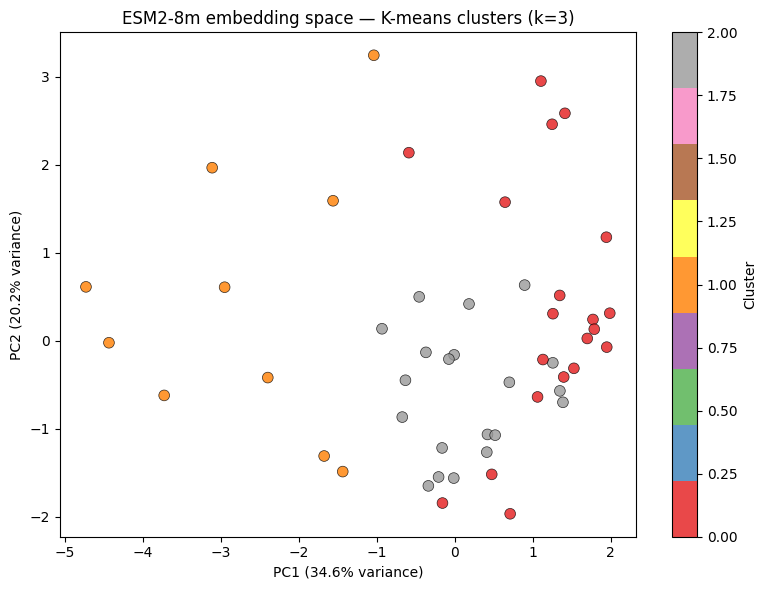

In [5]:
cluster_labels = [
    int(r[0]) for r in ds.conn.execute(
        "SELECT CAST(value AS INTEGER) FROM predictions WHERE prediction_type='cluster_k3' ORDER BY sequence_id"
    ).fetchall()
]

pca = PCA(n_components=2)
coords = pca.fit_transform(mat)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=cluster_labels,
                     cmap="Set1", edgecolors="black", linewidth=0.5, alpha=0.8, s=60)
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("ESM2-8m embedding space — K-means clusters (k=3)")
plt.tight_layout()
plt.show()

## Diversity sampling

Select 20 maximally diverse representatives spanning all clusters.

In [6]:
diverse_ds = DuckDBDataStore("diverse_demo.duckdb")

dp = DataPipeline(sequences=MY_50_PEPTIDES, datastore=diverse_ds, verbose=True)
dp.add_filter(ValidAminoAcidFilter(), stage_name="validate")
dp.add_prediction(
    "esm2-8m", action="encode",
    embedding_extractor=EmbeddingSpec(key="embeddings", layer=6),
    stage_name="embed", depends_on=["validate"],
)
dp.add_clustering(
    method="kmeans", n_clusters=3,
    similarity_metric="embedding", embedding_model="esm2-8m",
    stage_name="cluster", depends_on=["embed"],
)
dp.add_filter(DiversitySamplingFilter(n_samples=20, method="random"), stage_name="diverse_20")
dp.run()
dp.summary()

Added stage: FilterStage('validate')
Added stage: PredictionStage('embed', depends_on=['validate'])
Added stage: ClusteringStage('cluster', depends_on=['embed'])
Added stage: FilterStage('diverse_20', depends_on=['cluster'])

############################################################
# Pipeline: DataPipeline
# Run ID: 20260617_141556_d43fb8a4
# Initial sequences: 50
# Streaming: ENABLED
############################################################

Execution plan: 4 level(s)
  Level 1: validate
  Level 2: embed
  Level 3: cluster
  Level 4: diverse_20

Stage: validate
Input: 50 sequences
  Applying filter: ValidAminoAcidFilter(alphabet='ACDEFGHIKLMNPQRSTVWY')
  Filtered out: 0/50
  Remaining: 50

StageResult(validate: in=50, out=50, cached=0, computed=0, filtered=0, time=0.0s)

Stage: embed
Input: 50 sequences
Depends on: validate
  Cached: 0/50
  To compute: 50
  Calling esm2-8m.encode...


  esm2-8m:   0%|          | 0/2 [00:00<?, ?batch/s]

  Completed: 50 sequences in 2 batches (max 5 concurrent)

StageResult(embed: in=50, out=50, cached=0, computed=50, filtered=0, time=0.6s)

Stage: cluster
Input: 50 sequences
Depends on: embed
  Clustering 50 sequences using kmeans...
  Loading embeddings from esm2-8m...
  Found 3 clusters
  Silhouette score: 0.151

StageResult(cluster: in=50, out=50, cached=0, computed=50, filtered=0, time=0.1s)

Stage: diverse_20
Input: 50 sequences
Depends on: cluster
  Applying filter: DiversitySamplingFilter(n=20, method='random')
  Filtered out: 30/50
  Remaining: 20

StageResult(diverse_20: in=50, out=20, cached=0, computed=0, filtered=30, time=0.0s)

############################################################
# Pipeline completed in 0.8s
# Final sequences: 20
############################################################



,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,validate,50,50,0,0,0,0.0
1,embed,50,50,0,0,50,0.6
2,cluster,50,50,0,0,50,0.1
3,diverse_20,50,20,30,0,0,0.0


## Cleanup

In [7]:
ds.close(); diverse_ds.close()
import os
for f in ["cluster_demo.duckdb", "diverse_demo.duckdb"]:
    if os.path.exists(f): os.remove(f)

## Next Steps

Check out additional tutorials at [jupyter.biolm.ai](https://jupyter.biolm.ai),
or head over to our [BioLM Documentation](https://docs.biolm.ai) to explore
additional models and functionality.

#### See more use-cases and APIs on your [BioLM Console Catalog](https://biolm.ai/console/catalog/).
<br>

##### BioLM hosts deep learning models and runs inference at scale. You do the science.
<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/enzyme_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Enzyme Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/antibody_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Antibody Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/biosecurity_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Biosecurity
        </td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/single_cell_genomics_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Single-Cell Genomics
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/dna_seq_modeling_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> DNA Sequence Modelling
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/finetuning_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Finetuning
        </td>
    </tr>
</table>

#### [**Contact us**](https://biolm.ai/ui/contact-us/) to learn more.